In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import torch.nn.functional as F

from tokenizers.models import BPE
from tokenizers import Tokenizer
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace
from tokenizers.processors import TemplateProcessing

In [2]:
from pathlib import Path

In [3]:
train_path = Path("dataset/train")
public_path = Path("dataset/public_test")
private_path = Path("dataset/private_test")

In [4]:
zh, vi = [], []
with open(train_path / "train.zh", "r", encoding="utf-8") as f:
    zh = f.read().splitlines()

with open(train_path / "train.vi", "r", encoding="utf-8") as f:
    vi = f.read().splitlines()

print(len(zh), len(vi))
for i in range(5):
    print(zh[i], vi[i])

32061 32061
我 会 给 您 拿 一些 。 Tôi sẽ mang cho bạn một_ít . 
如果 你 还 有 什么 需要 的 就 告诉 我 。 Nếu bạn cần điều gì khác hãy cho tôi biết . 
不用 担心 那件 事 。 Đừng lo_lắng về điều đó . 
我 要 买 它 你 不 需要 把 它 包 起来 。 Tôi sẽ mang nó và bạn không cần phải gói nó lại . 
你 改变 吗 ？ Bạn thay_đổi không ? 


In [5]:
import pandas as pd

df= pd.DataFrame({
    "zh": zh,
    "vi": vi
}
)

In [6]:
df['vi'] = df['vi'].apply(lambda x: x.lower())
df.sample(5)

,zh,vi
16119,我 只 想 剪头 。,"làm_ơn cắt tóc ngắn cho tôi , không làm gì khá..."
25636,你 听 起来 很 累 ， 一切 可好 ？,"bạn nghe có_vẻ mệt , mọi việc ổn chứ ?"
7576,它 会 对 很多 公司 都 有用 的 。,nó sẽ hữu_ích cho nhiều công_ty .
17705,百货 大楼 在 什么 地方 ？,bách_hoá đại lầu ở chỗ nào ?
7661,这里 有点 太 宽松 了 。,ở đây nó quá lỏng_lẻo .


## Tokenizer

In [7]:
zh_tokenizer = Tokenizer(BPE(unk_token="[UNK]"))

vi_tokenizer = Tokenizer(BPE(unk_token="[UNK]"))
zh_trainer = BpeTrainer(
    vocab_size=15000,
    special_tokens = ["[SOS]", "[EOS]", "[PAD]", "[UNK]"],
    min_frequency = 3
)

vi_trainer = BpeTrainer(
    vocab_size=15000,
    special_tokens = ["[SOS]", "[EOS]", "[PAD]", "[UNK]"],
    min_frequency = 3 
)

def _yield(data):
    for sample in data:
        yield(sample)


zh_tokenizer.train_from_iterator(_yield(df['zh'].tolist()), zh_trainer)    
vi_tokenizer.train_from_iterator(_yield(df['vi'].tolist()), vi_trainer)    

In [8]:
zh_vocab = zh_tokenizer.get_vocab()
vi_vocab = vi_tokenizer.get_vocab()

print(len(zh_vocab), len(vi_vocab))

15000 15000


In [9]:
print(list(zh_vocab.keys())[:10])

['学生 。', '小型 ', '喝 杯 ', '她', '外套', ' 的 吗 ？', '帐户', '迪斯', '十分', '人们 ']


In [10]:
print(list(vi_vocab.keys())[:10])

[' tới đó ', 'en th', 'chúng_tôi đã ', 'lấy số ', 'tôi đã bỏ_lỡ ', 'lúc sáu giờ ', 'máy_ghi âm ', 'tiết_k', 'huế ', 'này tôi ']


In [11]:

ZH_PAD_TOKEN_ID = zh_tokenizer.token_to_id("[PAD]")
ZH_SOS_TOKEN_ID = zh_tokenizer.token_to_id("[SOS]")
ZH_EOS_TOKEN_ID = zh_tokenizer.token_to_id("[EOS]")

VI_PAD_TOKEN_ID = vi_tokenizer.token_to_id("[PAD]")
VI_SOS_TOKEN_ID = vi_tokenizer.token_to_id("[SOS]")
VI_EOS_TOKEN_ID = vi_tokenizer.token_to_id("[EOS]")

print(
    (ZH_PAD_TOKEN_ID, ZH_SOS_TOKEN_ID, ZH_EOS_TOKEN_ID),
    (VI_PAD_TOKEN_ID, VI_SOS_TOKEN_ID, VI_EOS_TOKEN_ID),
)

(2, 0, 1) (2, 0, 1)


Text(0.5, 1.0, 'vi')

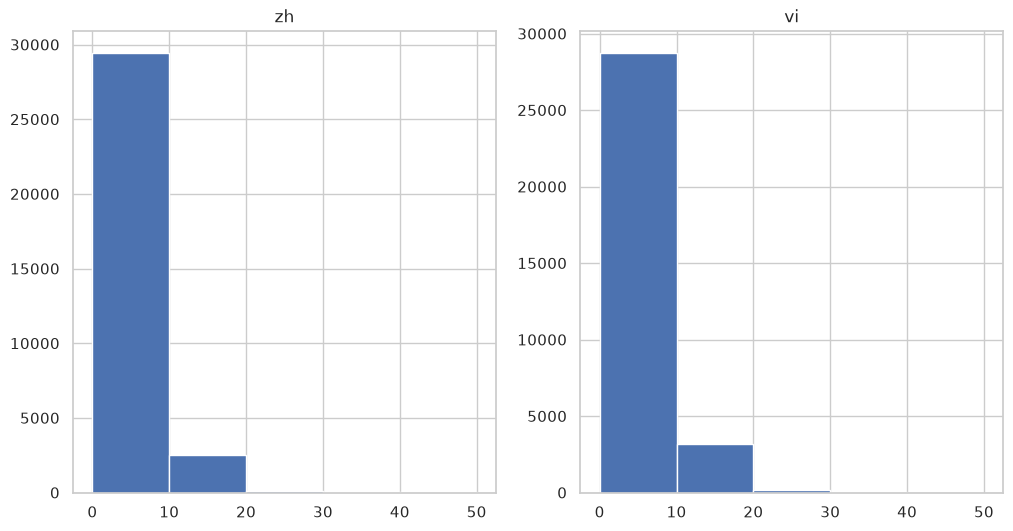

In [12]:
import matplotlib.pyplot as plt 
import seaborn as sns




sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

zh_count = df['zh'].apply(lambda x: len(zh_tokenizer.encode(x).ids)).tolist()
vi_count = df['vi'].apply(lambda x: len(vi_tokenizer.encode(x).ids)).tolist()
ax[0].hist(zh_count, range=(0,50), bins=5)
ax[0].set_title("zh")
ax[1].hist(vi_count, range=(0,50), bins=5)
ax[1].set_title("vi")

In [13]:
zh_tokenizer.post_processor = TemplateProcessing(
    single = "[SOS] $A [EOS]",
    special_tokens=[
       ("[SOS]" , ZH_SOS_TOKEN_ID),
       ("[EOS]" , ZH_EOS_TOKEN_ID),
    ]
)
vi_tokenizer.post_processor = TemplateProcessing(
    single = "[SOS] $A [EOS]",
    special_tokens=[
       ("[SOS]" , VI_SOS_TOKEN_ID),
       ("[EOS]" , VI_EOS_TOKEN_ID),
    ]
)

## Loading Data 

In [14]:
class CustomDataset(Dataset):
    def __init__(self, zh, vi, zh_tokenizer, vi_tokenizer, isTest=True):
        self.zh = zh
        self.vi = vi if not isTest else None 
        self.zh_tokenizer = zh_tokenizer
        self.vi_tokenizer = vi_tokenizer
        self.isTest = isTest
    def __len__(self) :
       return len(self.zh) 
    def __getitem__(self,idx):
        zh=  self.zh[idx] 
        zh_ids = self.zh_tokenizer.encode(zh).ids
        zh_ids = torch.tensor(zh_ids).squeeze(0)
        
        if self.isTest:
            return {
                "src": zh_ids,
                "tgt_input": None,
                "tgt_output": None
            }
        vi =  self.vi[idx] 
        vi_ids = self.vi_tokenizer.encode(vi).ids
        vi_ids = torch.tensor(vi_ids).squeeze(0)
        tgt_input = vi_ids[:-1]        
        tgt_output = vi_ids[1:]        
        return {
            "src": zh_ids,
            "tgt_input": tgt_input,
            "tgt_output": tgt_output
        }

In [15]:
df_train = df.sample(int(0.8 * len(df)), random_state=42)
df_val = df.drop(index=df_train.index)
len(df_train), len(df_val)

(25648, 6413)

In [16]:
train_data = CustomDataset(df_train['zh'].tolist(), df_train['vi'].tolist(), 
                           zh_tokenizer, vi_tokenizer, False)
val_data = CustomDataset(df_val['zh'].tolist(), df_val['vi'].tolist(), 
                           zh_tokenizer, vi_tokenizer, False)

In [17]:
train_data[10]

{'src': tensor([   0, 8133, 2630,    4,  308, 6670,  497, 3828, 2867, 3469,    1]),
 'tgt_input': tensor([   0, 7683, 5733, 6159, 5736]),
 'tgt_output': tensor([7683, 5733, 6159, 5736,    1])}

In [31]:
MAX_LEN = 25
def collate_fn(batch):
    src = [b["src"][:MAX_LEN ] for b in batch]
    tgt_input = [b["tgt_input"][:MAX_LEN ] for b in batch]
    tgt_output= [b["tgt_output"][:MAX_LEN ] for b in batch]

    src = nn.utils.rnn.pad_sequence(
        sequences=src, batch_first=True, padding_value=ZH_PAD_TOKEN_ID
    )
    tgt_input = nn.utils.rnn.pad_sequence(
        sequences=src, batch_first=True, padding_value=VI_PAD_TOKEN_ID
    )
    tgt_output = nn.utils.rnn.pad_sequence(
        sequences=src, batch_first=True, padding_value=VI_PAD_TOKEN_ID
    )

    src_key_padding_mask = src == VI_PAD_TOKEN_ID
    tgt_key_padding_mask = src == ZH_PAD_TOKEN_ID
    return {
       "src" : src,
       "tgt_input": tgt_input,
       "tgt_output": tgt_input,
       "src_key_padding_mask": src_key_padding_mask,
       "tgt_key_padding_mask": tgt_key_padding_mask,
    }

In [19]:
BATCH_SIZE = 64
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, collate_fn=collate_fn, shuffle=True)
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE, collate_fn=collate_fn, shuffle=False)

In [20]:
len(train_loader), len(val_loader)

(401, 101)

## Model

In [21]:
def create_mask(size, device):
    mask = torch.full((size, size), fill_value=float("inf"), device=device)
    mask = torch.triu(mask, diagonal=1)
    return mask


In [22]:
create_mask(4, 'cpu')

tensor([[0., inf, inf, inf],
        [0., 0., inf, inf],
        [0., 0., 0., inf],
        [0., 0., 0., 0.]])

In [23]:
class RMSNorm(nn.Module):
    def __init__(self, dim, eps = 1e-6):
        super().__init__()
        self.dim=  dim
        self.eps = eps
        self.scale = nn.Parameter(torch.ones(dim))
    def forward(self, x):
        rms = x.pow(2).mean(dim = -1, keepdim=True)
        x = x * torch.rsqrt(rms + self.eps)
        return x * self.scale

In [24]:
def rotate_half(x):
    x1, x2 = x.chunk(2, dim =-1)
    return torch.cat((x2, -x1), dim=  -1)

In [25]:
def rope_cache(dim, seq_len, device):
    half_dim = dim // 2
    angle = 1 / (10000 ** (torch.arange(0, half_dim, device=  device)/half_dim))
    positions = torch.arange(0, seq_len, device=device)
    angle = torch.outer(positions, angle)[None, :, None,  :]
    sin = torch.repeat_interleave(angle.sin(), 2, dim=-1)
    cos = torch.repeat_interleave(angle.cos(), 2, dim=-1)
    return sin, cos

In [26]:
def apply_rope(x, sin , cos):
    return x * sin + rotate_half(x) * cos

In [37]:
class Attension(nn.Module):
    def __init__(self, d_model, nhead, dropout ):
        super().__init__()
        self.d_model = d_model
        self.nhead = nhead
        self.dropout = nn.Dropout(dropout)
        self.scale = self.d_model ** -0.5
        self.q = nn.Linear(d_model, d_model)
        self.k = nn.Linear(d_model, d_model)
        self.v = nn.Linear(d_model, d_model)
        self.o = nn.Linear(d_model, d_model)
    def forward(self, q, k, v, attn_mask, key_padding_mask ):
        batch_size, q_len, _ = q.size(1)
        k_len = k.size(1)
        q = self.q(q).view(batch_size, q_len, self.nhead, self.d_model)
        k = self.k(k).view(batch_size, k_len, self.nhead, self.d_model)
        v = self.v(v).view(batch_size, k_len, self.nhead, self.d_model)
        
        sin, cos  = rope_cache(self.dim, max(q_len, k_len), q.device)
        q = apply_rope(q[:, :q_len, :, :], sin, cos)
        k = apply_rope(q[:, :k_len, :, :], sin, cos)
        weight = torch.matmul(q, k.transpose(1, -1)) * self.scale
        if attn_mask:
            weight = weight + attn_mask[None, :, None, :]
        if key_padding_mask:
            weight = torch.masked_fill(weight, key_padding_mask[:, :, None, None], float('-inf'))
        weight=  torch.softmax(weight, dim=-1)
        weight = self.dropout(weight)
        out = torch.matmul(weight, v)
        out = self.o(out).view(batch_size, q_len, self.dim)
        return out

In [38]:
class FeedForward(nn.Module):
    def __init__(self, dim, ffn, dropout):
        super().__init__()
        self.w1 = nn.Linear(dim, ffn)
        self.w2 = nn.Linear(dim, ffn)
        self.w3 = nn.Linear(ffn, dim)
        self.dropout = nn.Dropout(dropout)
    def forward(self, x):
        x = nn.funcional.silu(
            self.w1(x)) * self.w2(x)
        
        return self.w3(self.dropout(x))

In [43]:
class Encoder(nn.Module):
    def __init__(self, dim, nhead, ffn, dropout ):
        super().__init__()
        self.norm1 = RMSNorm(dim)
        self.norm2 = RMSNorm(dim)
        self.dropout = nn.Dropout(dropout)
        self.attn = Attension(dim, nhead, dropout)
        self.feed = FeedForward(dim, ffn, dropout)

        
    def forward(self, x, src_key_padding_mask):
        x = x + self.dropout(self.attn(
           self.norm1(x),
           self.norm1(x),
           self.norm1(x),
            None, src_key_padding_mask
        ))
        x = x + self.dropout(self.feed(self.norm2(x)))
        return x

In [39]:
class Decoder(nn.Module):
    def __init__(self, dim, nhead, ffn, dropout):
        super().__init__()
        self.norm1 = RMSNorm(dim)
        self.norm2 = RMSNorm(dim)
        self.norm3 = RMSNorm(dim)
        self.att1 = Attension(dim, nhead, dropout)
        self.att2 = Attension(dim, nhead, dropout)
        self.feed = FeedForward(dim, ffn, dropout)
    def forward(self, memory, memory_key_padding_mask, tgt, tgt_mask, tgt_key_padding_mask):
        tgt = tgt + self.dropout(self.attn1(
           self.norm1(tgt),
           self.norm1(tgt),
           self.norm1(tgt),
            tgt_mask, tgt_key_padding_mask
        ))
        tgt = tgt + self.dropout(self.attn2(
           self.norm2(tgt),
           memory,
           memory,
            None, memory_key_padding_mask
        ))
        tgt = tgt  + self.dropout(self.feed(self.norm3(tgt)))
        return tgt

In [46]:
class NMT(nn.Module):
    def __init__(self, dim, nhead, zh_size, vi_size, dropout, ffn, num_encoders, num_decoders):
        super().__init__()
        self.zh_embedd = nn.Embedding(zh_size, dim)
        self.vi_embedd = nn.Embedding(vi_size, dim)
        self.encoder = nn.ModuleList(
            Encoder(dim, nhead, ffn, dropout) for _ in range(num_encoders)
        )
        self.decoder = nn.ModuleList(
            Decoder(dim, nhead, ffn, dropout) for _ in range(num_decoders)
        )
        self.dropout = nn.Dropout(dropout)
        self.norm = RMSNorm(dim)
        self.head=  nn.Linear(dim, vi_size, bias= False)
    def forward(self, src, src_key_padding_mask,
                tgt, tgt_mask, tgt_key_padding_mask):
        src = self.dropout(self.zh_embedd(src))
        memory = src
        for layer in self.encoder:
            memory = layer(memory, src_key_padding_mask)
        
        tgt = self.dropout(self.vi_embedd(tgt))
        for layer in self.decoder:
            tgt = layer(memory, src_key_padding_mask, tgt, tgt_mask, tgt_key_padding_mask)
        out = self.head(self.norm(tgt))


In [35]:
DIM = 384
NHEAD = 6
ZH_SIZE = 15000
VI_SIZE = 15000
NUM_ENCODERS = 6
NUM_DECODERS = 6
FFN = 1536
DROPOUT = 0.1

In [47]:
model = NMT(DIM, NHEAD, ZH_SIZE, VI_SIZE,DROPOUT, FFN, NUM_ENCODERS, NUM_DECODERS )

In [50]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
model = model.to(DEVICE)

In [ ]:
total_params = 0
for p in model.parameters():
    total_params += p.numel()
print(total_params)

49211520


In [52]:
criterion = nn.CrossEntropyLoss(ignore_index=VI_PAD_TOKEN_ID, label_smoothing=0.1)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    betas=(0.9, 0.98),
    weight_decay=1e-4,
)

## Training

In [51]:
from tqdm import tqdm
from torch.nn.utils import clip_grad_norm_

In [61]:

def train(epoch, epochs, train_loader, scheduler):
    model.train()
    correct, count, losses = 0, 0, []

    for inputs in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]"):
        src = inputs["src"].to(DEVICE)
        tgt_input = inputs["tgt_input"].to(DEVICE)
        tgt_output = inputs["tgt_output"].to(DEVICE)
        src_key_padding_mask = inputs["src_key_padding_mask"].to(DEVICE)
        tgt_key_padding_mask = inputs["tgt_key_padding_mask"].to(DEVICE)
        tgt_mask = create_mask(tgt_input.size(1), DEVICE)

        optimizer.zero_grad(set_to_none=True)
        output = model(
            src,
            src_key_padding_mask,
            tgt_input,
            tgt_mask,
            tgt_key_padding_mask
        )
        loss = criterion(output, tgt_output)
        losses.append(loss.item())
        pred = output.argmax(1)
        non_pad_mask = tgt_output != VI_PAD_TOKEN_ID
        correct += (pred[non_pad_mask] == tgt_output[non_pad_mask]).sum().item()
        loss.backward()
        clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        count += non_pad_mask.sum().item()

    epoch_loss = sum(losses) / len(losses)
    epoch_acc = correct / count
    return epoch_acc, epoch_loss


In [62]:
def evaluate(epoch, epochs, val_loader):
    model.eval()
    correct, count, losses = 0, 0, []
    with torch.no_grad():
        for inputs in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]"):
            src = inputs["src"].to(DEVICE)
            tgt_input = inputs["tgt_input"].to(DEVICE)
            tgt_output = inputs["tgt_output"].to(DEVICE)
            src_key_padding_mask = inputs["src_key_padding_mask"].to(DEVICE)
            tgt_key_padding_mask = inputs["tgt_key_padding_mask"].to(DEVICE)
            tgt_mask = create_mask(tgt_input.size(1))

            output = model(
                src,
                src_key_padding_mask,
                tgt_input,
                tgt_mask,
                tgt_key_padding_mask
            )
            loss = criterion(output, tgt_output)
            losses.append(loss.item())
            pred = output.argmax(1)
            non_pad_mask = tgt_output != VI_PAD_TOKEN_ID
            correct += (pred[non_pad_mask] == tgt_output[non_pad_mask]).sum().item()
            count += non_pad_mask.sum().item()

    epoch_loss = sum(losses) / len(losses)
    epoch_acc = correct / count
    return epoch_acc, epoch_loss


In [56]:
import sacrebleu
@torch.no_grad()
def compute_bleu(zhs, vis):
    preds = []
    for zh in zhs:
        src = zh_tokenizer.encode(zh).ids
        src = torch.tensor(src, device=DEVICE).unsqueeze(0)
        src_key_padding_mask = src == ZH_PAD_TOKEN_ID
        
        ys = torch.tensor([[VI_SOS_TOKEN_ID]], dtype=torch.long, device=DEVICE)
        max_len = src.size(1) + 5

        for i in range(max_len - 1):
            tgt_mask = create_mask(ys.size(1)).to(DEVICE)
            tgt_key_padding_mask = ys == ZH_PAD_TOKEN_ID
            
            output = model(
                src,
                src_key_padding_mask,
                ys,
                tgt_mask,
                tgt_key_padding_mask
            )
            pred = output[:, :, -1].argmax(1).item()
            ys = torch.cat(
                (ys, torch.tensor([[pred]])), dtype = torch.long, device=DEVICE, dim =1
            )
            
            if pred == VI_EOS_TOKEN_ID:
                break 
            
        pred = vi_tokenizer.decode(ys.squeeze(0).tolist(), skip_special_tokens=True)
        preds.append(pred)
    bleu = sacrebleu.corpus_bleu(pred, vis, force=True)
    return bleu.score

ModuleNotFoundError: No module named 'sacrebleu'

In [57]:

train_losses, val_losses, train_accs, val_accs, bleu_scores = [], [], [], [], []

In [65]:
min_loss = 10

In [66]:
def training(epochs, train_loader, test_loader, bleu_every=2):
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=3e-4,
        total_steps=epochs * len(train_loader),
        pct_start=0.1,
        anneal_strategy="cos",
        div_factor=10.0,
        final_div_factor=100.0,
    )
    model_path = "./model.pth"
    zh_tokenizer_path = "./zh_tokenizer.json"
    zh_tokenizer.save(zh_tokenizer_path)

    vi_tokenizer_path = "./vi_tokenizer.json"
    vi_tokenizer.save(vi_tokenizer_path)
    for epoch in range(epochs):
        train_acc, train_loss = train(epoch, epochs, train_loader, scheduler)
        val_acc, val_loss = evaluate(epoch, epochs, test_loader)
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        val_losses.append(val_loss)
        val_accs.append(val_acc)
        if val_loss < min_loss:
            torch.save(model.state_dict(), model_path)
            
        bleu_score = None
        if epoch % bleu_every == 0 or epoch == epochs - 1:
            bleu_score = compute_bleu(
                df_val["zh"].tolist(),
                df_val["vi"].tolist(),
            )
            bleu_scores.append(bleu_score)

        print(f"  Train Loss: {train_loss:.4f}, Train Acc: {train_acc*100:.2f}%")
        print(f"  Val Loss: {val_loss:.4f}, Val Acc: {val_acc*100:.2f}%")
        if bleu_score is None:
            print("  Val BLEU: skipped\n")
        else:
            print(f"  Val BLEU: {bleu_score:.2f}\n")


In [64]:

training(
    epochs=35, train_loader=train_loader, test_loader=val_loader
)

Epoch 1/35 [Train]:   0%|          | 0/401 [00:00<?, ?it/s]


TypeError: cannot unpack non-iterable int object